In [1]:
import polars as pl
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
SEED = 4130

In [2]:
accounts = pl.read_csv(
    "../Data/accounts.csv",
    null_values="NULL",
    schema_overrides={
        "account_number": pl.String,
        "price": pl.Float64,
        "churned": pl.Int64
    }
)
accounts.head()

account_number,price,churned
str,f64,i64
"""650""",30.56,1
"""573""",12.04,0
"""575""",32.05,0
"""943""",30.56,1
"""924""",35.19,0


In [3]:
streams = (
    pl.read_csv(
        "../Data/streams.csv",
        null_values="NULL",
        schema_overrides={
            "account_number": pl.String,  
            "start_timestamp": pl.Int64,  
            "end_timestamp": pl.Int64,    
            "mos_score": pl.Float64
        }
    )
    .with_columns(
        pl.col("start_timestamp").cast(pl.Datetime("ms")),
        pl.col("end_timestamp").cast(pl.Datetime("ms"))
    )
)
streams.head()

account_number,start_timestamp,end_timestamp,mos_score
str,datetime[ms],datetime[ms],f64
"""978""",2018-05-20 00:17:03.142,2018-05-20 00:18:05.544,4.531915
"""599""",2018-05-19 08:29:28.735,2018-05-19 08:42:48.844,4.595745
"""939""",2018-05-19 22:24:31.819,2018-05-19 22:29:41.833,4.06383
"""939""",2018-05-19 23:34:15.013,2018-05-19 23:59:20.750,4.468085
"""749""",2018-05-19 13:59:00.947,2018-05-19 14:32:46.937,4.595745


In [4]:
average_churn = accounts['churned'].mean()
average_churn

0.413

In [5]:
(
    accounts
    .group_by(has_streams = pl.col("account_number").is_in(streams["account_number"].implode()))
    .agg(
        n_users = pl.len(),
        prop_churned = pl.col("churned").mean().round(2)
    )
)

has_streams,n_users,prop_churned
bool,u32,f64
true,546,0.23
false,454,0.63


In [6]:
bottom_10_mos = round(streams["mos_score"].quantile(0.1), 1)
bottom_10_mos

3.5

In [7]:
global_max_date = streams.select(pl.col("start_timestamp").dt.date().max()).item()
seven_days_ago = global_max_date - timedelta(days=7)
fourteen_days_ago = global_max_date - timedelta(days=14)
twentyone_days_ago = global_max_date - timedelta(days=21)
thirty_days_ago = global_max_date - timedelta(days=30)
sixty_days_ago = global_max_date - timedelta(days=60)

streaming_features = (
    streams
    .with_columns(
        stream_duration = (pl.col("end_timestamp") - pl.col("start_timestamp")),
        stream_date = pl.col("start_timestamp").dt.date()
    )
    .group_by(pl.col("account_number"))
    .agg(
        n_streams = pl.len(),
        total_time_streamed = pl.col("stream_duration").sum().dt.total_seconds(),
        avg_stream_length = pl.col("stream_duration").sum().dt.total_seconds() / pl.len(),
        days_streamed = pl.col("stream_date").n_unique(),
        avg_mos_score = (pl.col("mos_score") * pl.col("stream_duration")).sum() / pl.col("stream_duration").sum(),
        days_since_last_stream = (global_max_date - pl.col("stream_date").max()).dt.total_days(),
        n_poor_quality_streams = (pl.col("mos_score") < bottom_10_mos).sum(),
        n_aborted_streams = (pl.col("stream_duration").dt.total_seconds() < 300).sum(),
        max_streams_per_day = pl.col("stream_date").value_counts().struct.field("count").max(),
        avg_streams_per_active_day = pl.len() / pl.col("stream_date").n_unique(),
        streams_last_7d = (pl.col("stream_date") >= seven_days_ago).sum(),
        streams_last_14d = (pl.col("stream_date") >= fourteen_days_ago).sum(),
        streams_last_21d = (pl.col("stream_date") >= twentyone_days_ago).sum(),
        streams_last_30d = (pl.col("stream_date") >= thirty_days_ago).sum(),
        streams_last_60d = (pl.col("stream_date") >= sixty_days_ago).sum(),
    )
)
streaming_features.head()

account_number,n_streams,total_time_streamed,avg_stream_length,days_streamed,avg_mos_score,days_since_last_stream,n_poor_quality_streams,n_aborted_streams,max_streams_per_day,avg_streams_per_active_day,streams_last_7d,streams_last_14d,streams_last_21d,streams_last_30d,streams_last_60d
str,u32,i64,f64,u32,f64,i64,u32,u32,u32,f64,u32,u32,u32,u32,u32
"""409""",41,2680,65.365854,10,4.36061,8,2,40,17,4.1,0,3,3,6,8
"""291""",299,704279,2355.448161,43,4.365891,6,18,52,24,6.953488,10,34,74,110,125
"""838""",772,602646,780.629534,84,4.455241,1,30,384,41,9.190476,71,113,200,271,388
"""362""",404,430917,1066.626238,72,4.317829,0,39,189,26,5.611111,100,143,155,191,231
"""686""",98,131305,1339.846939,20,3.435235,0,43,44,21,4.9,51,64,65,69,82


In [8]:
customer_data = (
    accounts.join(streaming_features, on="account_number", how="left", validate="1:1")
    .with_columns(
        is_inactive = (pl.col("n_streams") == 0) | pl.col("n_streams").is_null(),
        cost_per_stream = pl.col("total_time_streamed") / pl.col("price")
    )
)
customer_data.head()

account_number,price,churned,n_streams,total_time_streamed,avg_stream_length,days_streamed,avg_mos_score,days_since_last_stream,n_poor_quality_streams,n_aborted_streams,max_streams_per_day,avg_streams_per_active_day,streams_last_7d,streams_last_14d,streams_last_21d,streams_last_30d,streams_last_60d,is_inactive,cost_per_stream
str,f64,i64,u32,i64,f64,u32,f64,i64,u32,u32,u32,f64,u32,u32,u32,u32,u32,bool,f64
"""650""",30.56,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,true,null
"""573""",12.04,0,492,667736,1357.186992,61,2.122296,7,210,314,86,8.065574,2,3,22,127,175,false,55459.800664
"""575""",32.05,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,true,null
"""943""",30.56,1,8,9815,1226.875,1,1.928656,75,6,2,8,8.0,0,0,0,0,0,false,321.171466
"""924""",35.19,0,1614,1887842,1169.666667,98,4.462582,0,62,625,48,16.469388,119,205,279,430,671,false,53647.115658


In [9]:
# train/validation/test split with stratification on churned variable
analysis_df = customer_data.drop(pl.col(["account_number"]))

# 80% train
train_df, temp_df = train_test_split(
    analysis_df, 
    test_size=0.20,
    stratify=customer_data["churned"],
    random_state=SEED
)

# 10% validation, 10% test
test_df, valid_df = train_test_split(
    temp_df, 
    test_size=0.50,
    stratify=temp_df["churned"],
    random_state=SEED
)

X_train, y_train = train_df.drop("churned"), train_df.select("churned")
X_valid, y_valid = valid_df.drop("churned"), valid_df.select("churned")
X_test, y_test = test_df.drop("churned"), test_df.select("churned")

print(f"n_features: {X_train.width}")
print(f"training_customers: {X_train.height}")
print(f"validation_customers: {X_valid.height}")
print(f"test_customers: {X_test.height}")

n_features: 18
training_customers: 800
validation_customers: 100
test_customers: 100


In [10]:
# calculate scale_pos_weight to handle class imbalance
n_churned = (y_train == 1).sum().item()
n_stayed = (y_train == 0).sum().item()
scale_pos_weight = n_stayed / n_churned
scale_pos_weight

1.4242424242424243

In [11]:
# randomized search for hyperparameter tuning with 3-fold cross-validation
base_model = xgb.XGBClassifier(
    n_estimators=500,
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=SEED
)

param_distributions = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

tuning_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=100,
    scoring='average_precision', # score models using AUC-PR
    cv=3,                 
    verbose=0,
    random_state=SEED,
    n_jobs=1
)

tuning_search.fit(
    X_train,
    y_train,
    verbose=False
)

best_params = tuning_search.best_params_
best_params

{'subsample': 0.7,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.9}

In [12]:
# fit final model with best hyperparameters and early stopping
final_model = xgb.XGBClassifier(
    n_estimators=2000,
    eval_metric="aucpr",
    early_stopping_rounds=100,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    **best_params
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=25
)

[0]	validation_0-aucpr:0.70998
[25]	validation_0-aucpr:0.70454
[50]	validation_0-aucpr:0.72447
[75]	validation_0-aucpr:0.72901
[100]	validation_0-aucpr:0.73561
[102]	validation_0-aucpr:0.73670


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [13]:
# print best validation PR-AUC score
final_model.best_score

0.7397047072594547

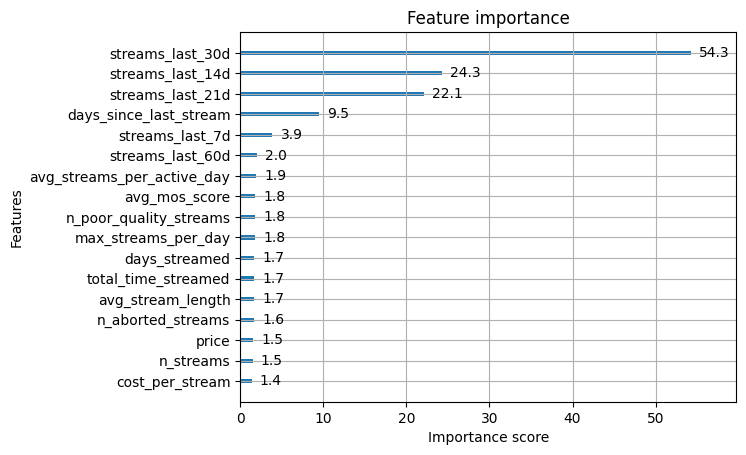

In [14]:
# plot feature importance (gain)
xgb.plot_importance(final_model, importance_type="gain", values_format="{v:.1f}")
plt.show()

In [15]:
# calculate optimal threshold based on F1-score
y_pred_proba_valid = final_model.predict_proba(X_valid)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_pred_proba_valid)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal PR Threshold (Max F1): {optimal_threshold:.4f}\n")

Optimal PR Threshold (Max F1): 0.4814



In [16]:
# predict on test set and calculate PR-AUC
y_pred_proba_test = final_model.predict_proba(X_test)[:, 1]
pr_auc_score = average_precision_score(y_test, y_pred_proba_test)
print(f"PR-AUC Score: {pr_auc_score:.4f}")

# apply threshold to get hard predictions
y_pred_test = (y_pred_proba_test >= optimal_threshold).astype(int)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_test))

PR-AUC Score: 0.7462
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.76      0.82        58
           1       0.73      0.88      0.80        42

    accuracy                           0.81       100
   macro avg       0.81      0.82      0.81       100
weighted avg       0.83      0.81      0.81       100



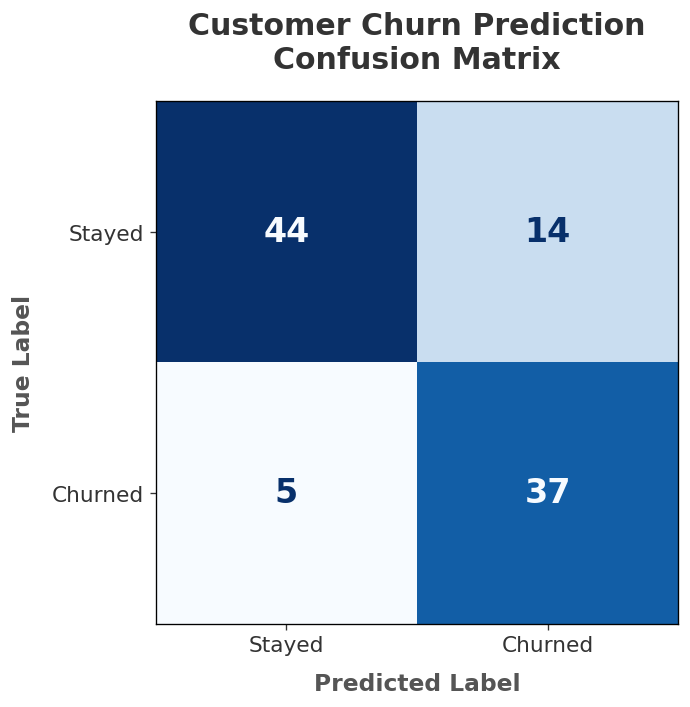

In [17]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# 1. Create a figure with a professional size and higher resolution (dpi)
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Stayed', 'Churned']
)

# 2. Plot on the specific axis, increase the font size further, and remove the colorbar
disp.plot(
    cmap='Blues', 
    values_format='d', 
    ax=ax, 
    text_kw={'fontsize': 20, 'fontweight': 'bold'}, # Increased font size and made it bold
    colorbar=False # Removes the color sidebar
) 

# 3. Make the title larger, bold, and give it some padding so it doesn't crowd the chart
ax.set_title("Customer Churn Prediction\nConfusion Matrix", fontsize=18, pad=20, fontweight='bold', color='#333333')

# 4. Increase the size of the x and y axis labels
ax.set_xlabel("Predicted Label", fontsize=14, fontweight='bold', labelpad=10, color='#555555')
ax.set_ylabel("True Label", fontsize=14, fontweight='bold', labelpad=10, color='#555555')

# 5. Increase the size of the tick labels (the "Stayed" and "Churned" text)
ax.tick_params(axis='both', which='major', labelsize=13, colors='#333333')

# Ensure nothing gets cut off
plt.tight_layout()

# Render the plot
plt.show()